# Heart Disease Prediction using Machine Learning

This notebook demonstrates the process of building a machine learning model to predict heart disease using the UCI Heart Disease Dataset. It covers data loading, preprocessing, model training, and evaluation.

Dataset loaded successfully.
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   28    1   2     130.0  132.0  0.0      2.0    185.0    0.0      0.0   
1   29    1   2     120.0  243.0  0.0      0.0    160.0    0.0      0.0   
2   29    1   2     140.0    NaN  0.0      0.0    170.0    0.0      0.0   
3   30    0   1     170.0  237.0  0.0      1.0    170.0    0.0      0.0   
4   31    0   2     100.0  219.0  0.0      1.0    150.0    0.0      0.0   

   slope  ca  thal  target  
0    NaN NaN   NaN       0  
1    NaN NaN   NaN       0  
2    NaN NaN   NaN       0  
3    NaN NaN   6.0       0  
4    NaN NaN   NaN       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  293 non-null    

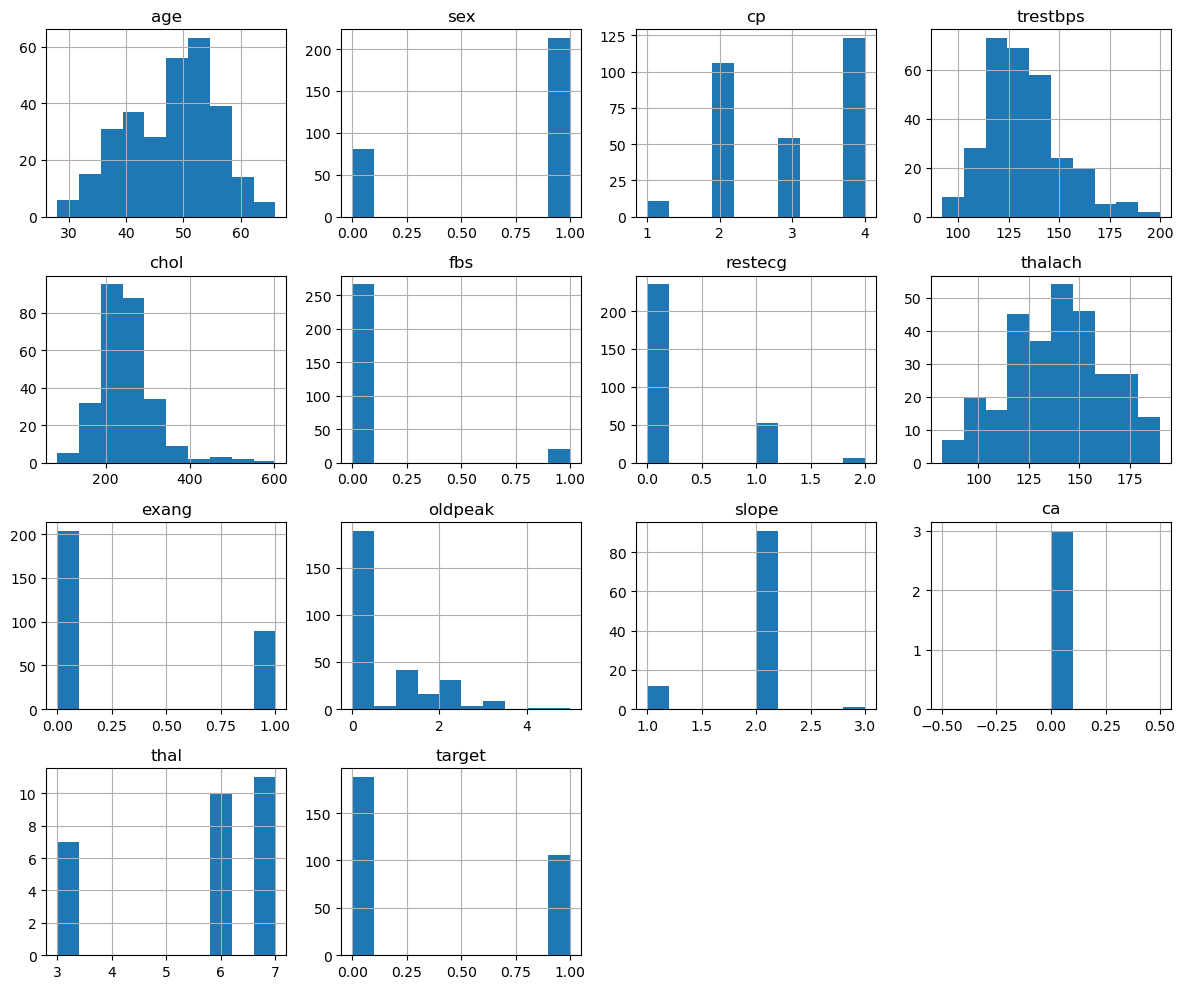

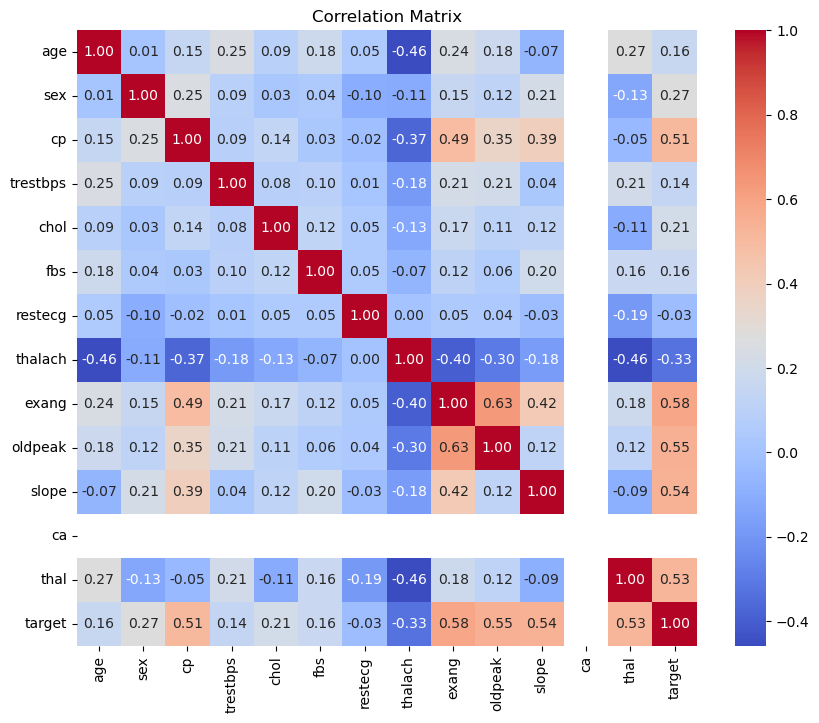

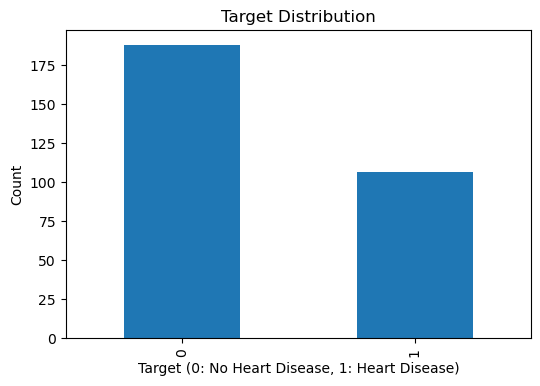

Starting tabular data preprocessing...
Tabular data preprocessing complete.

Shape of preprocessed features: (294, 25)
First 5 rows of preprocessed features:
        age  trestbps      chol   thalach   oldpeak   ca  sex_0.0  sex_1.0  \
0 -2.542347 -0.147076 -1.833027  1.951150 -0.646074  0.0      0.0      1.0   
1 -2.414117 -0.716341 -0.121052  0.887744 -0.646074  0.0      0.0      1.0   
2 -2.414117  0.422189  0.000000  1.313106 -0.646074  0.0      0.0      1.0   
3 -2.285888  2.129984 -0.213591  1.313106 -0.646074  0.0      1.0      0.0   
4 -2.157658 -1.854871 -0.491209  0.462382 -0.646074  0.0      1.0      0.0   

   cp_1.0  cp_2.0  ...  restecg_1.0  restecg_2.0  exang_0.0  exang_1.0  \
0     0.0     1.0  ...          0.0          1.0        1.0        0.0   
1     0.0     1.0  ...          0.0          0.0        1.0        0.0   
2     0.0     1.0  ...          0.0          0.0        1.0        0.0   
3     1.0     0.0  ...          1.0          0.0        1.0        0.0   
4  

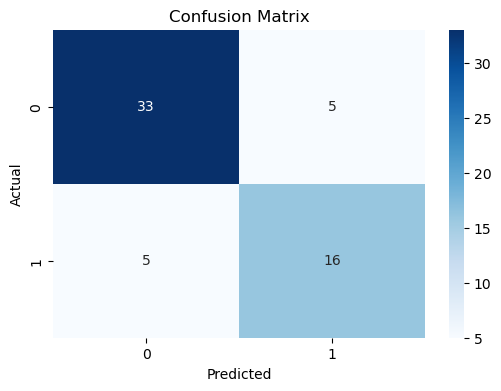

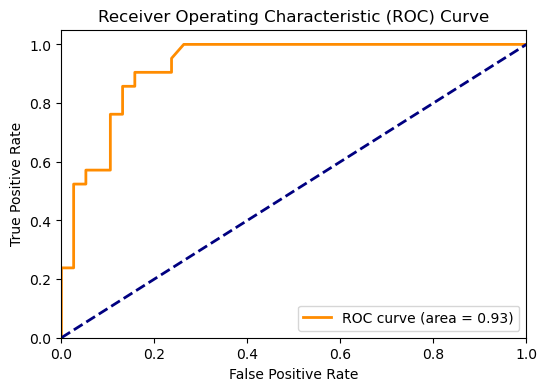

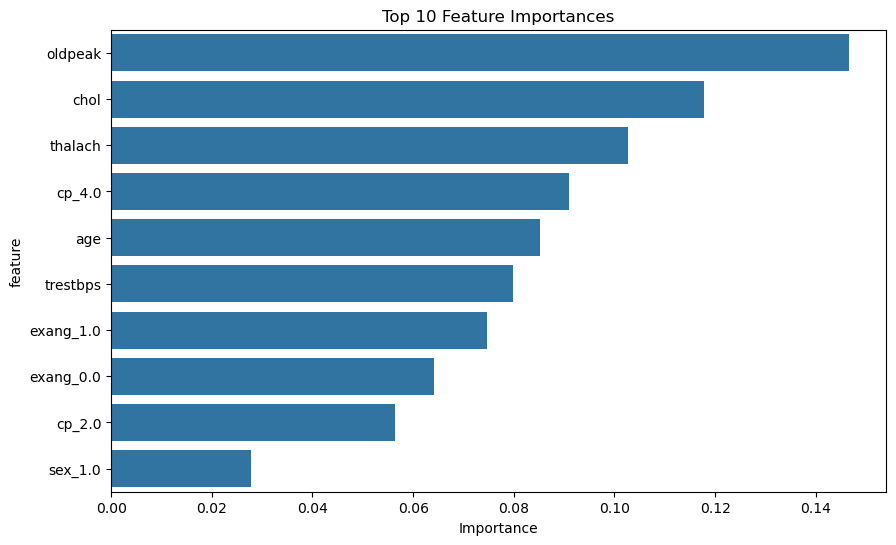

Model and preprocessor saved.


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Import data_preprocessing utility
# Adjust this to point to your project's root directory
sys.path.append(os.path.abspath('../'))

from src.utils.data_preprocessing import preprocess_tabular_data

# --- 1. Data Loading ---
# Ensure you have downloaded the UCI Heart Disease Dataset and placed it in the correct path.
# Download from: https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as heart_disease.csv in a "data/raw/" directory relative to your notebook.

data_path = "../data/raw/heart_disease/processed.hungarian.data" # Adjust path as necessary

# Column names for the heart disease dataset
column_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

try:
    data = pd.read_csv(data_path, names=column_names, na_values='?')
    print("Dataset loaded successfully.")
    print(data.head())
except FileNotFoundError:
    print(f"Error: {data_path} not found. Please download the dataset and place it correctly.")
    # Create dummy data for demonstration if file not found
    print("Creating dummy data for demonstration.")
    data = pd.DataFrame({
        "age": np.random.randint(30, 80, 100),
        "sex": np.random.randint(0, 2, 100),
        "cp": np.random.randint(0, 4, 100),
        "trestbps": np.random.randint(90, 200, 100),
        "chol": np.random.randint(120, 400, 100),
        "fbs": np.random.randint(0, 2, 100),
        "restecg": np.random.randint(0, 3, 100),
        "thalach": np.random.randint(70, 200, 100),
        "exang": np.random.randint(0, 2, 100),
        "oldpeak": np.random.uniform(0, 6, 100),
        "slope": np.random.randint(0, 3, 100),
        "ca": np.random.randint(0, 4, 100),
        "thal": np.random.randint(0, 4, 100),
        "target": np.random.randint(0, 2, 100)
    })

# --- 2. Exploratory Data Analysis (EDA) ---
print("\nDataset Info:")
data.info()

print("\nDataset Description:")
data.describe()

print("\nMissing values:")
print(data.isnull().sum())

# Visualize distribution of features
data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Target distribution
plt.figure(figsize=(6, 4))
data["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target (0: No Heart Disease, 1: Heart Disease)")
plt.ylabel("Count")
plt.show()

# --- 3. Data Preprocessing ---
# Define columns for preprocessing
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
target_column = "target"

X_processed, y, preprocessor = preprocess_tabular_data(data, numerical_cols, categorical_cols, target_column)

print("\nShape of preprocessed features:", X_processed.shape)
print("First 5 rows of preprocessed features:")
print(X_processed.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# --- 4. Model Building (Random Forest) ---
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete.")

# --- 5. Model Evaluation ---
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    "feature": X_processed.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# --- 6. Save Model (Optional) ---
import joblib
joblib.dump(model, "heart_disease_random_forest_model.pkl")
joblib.dump(preprocessor, "heart_disease_preprocessor.pkl")
print("Model and preprocessor saved.")
